In [1]:
# 制御設計に用いるライブラリ

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sympy as sp
import control
from control.matlab import *
sp.init_printing()

In [2]:
# グラフの線種を決めるジェネレータ関数
def linestyle_generator():
    linestyle = ['-', '--', '-.', ':']
    lineID = 0
    while True:
        yield linestyle[lineID]
        lineID = (lineID + 1) % len(linestyle)
        
# グラフを整える関数
def plot_set(fig_ax, *args):
    fig_ax.set_xlabel(args[0])
    fig_ax.set_ylabel(args[1])
    fig_ax.grid(ls=':')
    if len(args)==3:
        fig_ax.legend(loc=args[2])
        
# ボード線図を整える関数
def bodeplot_set(fig_ax, *args):
    # draw Gain
    fig_ax[0].grid(which="both", ls=':')
    fig_ax[0].set_ylabel('Gain [dB]')
    # draw Phase
    fig_ax[1].grid(which="both", ls=':')
    fig_ax[1].set_xlabel('Omega [rad/s]')
    fig_ax[1].set_ylabel('Phase [deg]')
    # 凡例の表示
    if len(args) > 0:
        fig_ax[0].legend(loc=args[0])
    if len(args) > 1:
        fig_ax[1].legend(loc=args[1])


### 1. 状態空間モデル

システムを四つの行列で定義する

${x}$ を状態量、 ${u}$ を操作量、 ${y}$ を観測量としシステムは次の連立方程式で表す。

$$
\begin{cases}
\dot{x} &= Ax + Bu \\
y &= Cx + Du
\end{cases}
$$

${A, B, C, D}$ をそれぞれ「状態行列」「入力行列」「観測行列」「直達行列」という

#### 1.2 1自由度振動系

質量の運動を表す微分方程式は、「${m k \mu}$」を「質点の質量」、「バネ定数」、

「ダンピング定数」、質点に作用する力を ${u}$ とすると、

${m\ddot{z} + \mu\dot{z} + kz = u}

状態量 ${x}$ を 

$\begin{bmatrix} z \\ \dot{z} \end{bmatrix}$

とすることで、状態方程式

${\dot{x} = Ax + bu}$

ここで、 ${A = \begin{bmatrix} 0 & 1 \\ -k/m & -\mu/m \end{bmatrix}}$ 、
$\begin{bmatrix} 0 \\ 1/m \end{bmatrix}$

観測量を質点の位置 ${z}$ とすると、

${y = \begin{bmatrix} 1 & 0 \end{bmatrix}\begin{bmatrix} z \\ \dot{z} \end{bmatrix}} {= cx}$


### 2. システムの安定性

#### 2.1 状態空間モデルの時間応答

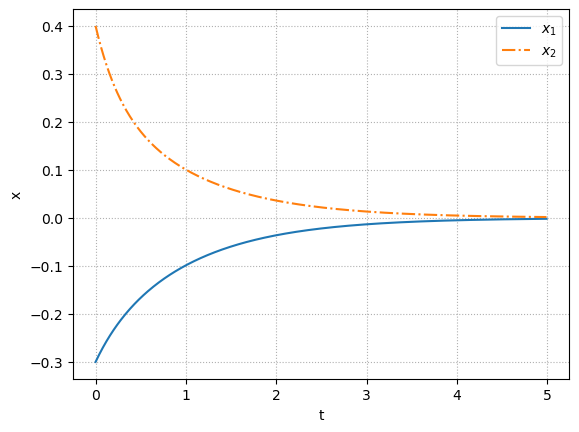

In [3]:
# 初期値応答（零入力応答）

A = [[0, 1], [-4, -5]]
B = [[0], [1]]
C = np.eye(2)
D = np.zeros([2, 1])
P = ss(A, B, C, D)

Td = np.arange(0, 5, 0.01)
X0 = [-0.3, 0.4]
x, t = initial(P, Td, X0)

fig, ax = plt.subplots()
ax.plot(t, x[:,0], label='$x_1$')
ax.plot(t, x[:,1], ls='-.', label='$x_2$')
plot_set(ax, 't', 'x', 'best')

In [4]:
import sympy as sp

# 記号
t = sp.Symbol('t', positive=True)

# 行列 A（SymPy で定義）
A = sp.Matrix([[0, 1],
               [-4, -5]])

# 行列指数関数 e^{At}
exp_At = sp.exp(A*t)

exp_At

⎡     -t    -4⋅t       -t    -4⋅t  ⎤
⎢  4⋅ℯ     ℯ          ℯ     ℯ      ⎥
⎢  ───── - ─────      ─── - ─────  ⎥
⎢    3       3         3      3    ⎥
⎢                                  ⎥
⎢     -t      -4⋅t     -t      -4⋅t⎥
⎢  4⋅ℯ     4⋅ℯ        ℯ     4⋅ℯ    ⎥
⎢- ───── + ───────  - ─── + ───────⎥
⎣    3        3        3       3   ⎦

In [5]:
import sympy as sp
import numpy as np

s = sp.Symbol('s')
t = sp.Symbol('t', positive=True)

A = np.array([[0, 1], [-4, -5]])
G = s*sp.eye(2) - A
exp_At = sp.inverse_laplace_transform(sp.simplify(G.inv()), s, t)
display(exp_At)

⎡     -t    -4⋅t       -t    -4⋅t  ⎤
⎢  4⋅ℯ     ℯ          ℯ     ℯ      ⎥
⎢  ───── - ─────      ─── - ─────  ⎥
⎢    3       3         3      3    ⎥
⎢                                  ⎥
⎢     -t      -4⋅t     -t      -4⋅t⎥
⎢  4⋅ℯ     4⋅ℯ        ℯ     4⋅ℯ    ⎥
⎢- ───── + ───────  - ─── + ───────⎥
⎣    3        3        3       3   ⎦

In [6]:
x0 = sp.Matrix([-0.3, 0.4])   # 例
x_t = exp_At * x0
x_t

⎡                     -t                       -4⋅t⎤
⎢- 0.266666666666667⋅ℯ   - 0.0333333333333333⋅ℯ    ⎥
⎢                                                  ⎥
⎢                    -t                      -4⋅t  ⎥
⎣ 0.266666666666667⋅ℯ   + 0.133333333333333⋅ℯ      ⎦

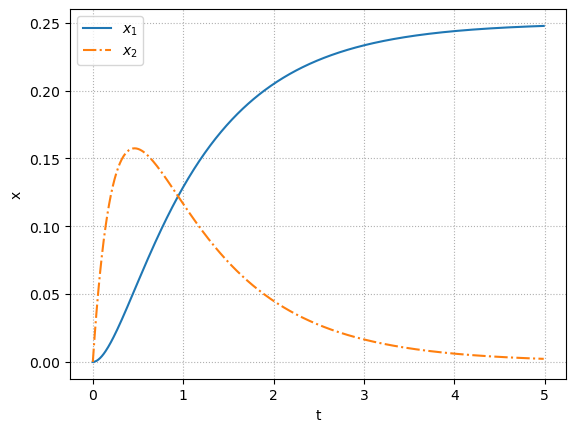

In [10]:
# 零状態応答（ステップ応答）

Td = np.arange(0, 5, 0.01)
x, t = step(P, Td)

fig, ax = plt.subplots()
ax.plot(t, x[:,0], label='$x_1$')
ax.plot(t, x[:,1], ls='-.', label='$x_2$')
plot_set(ax, 't', 'x', 'best')

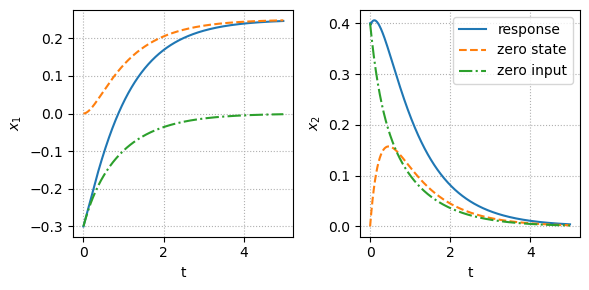

In [7]:
# 状態空間モデルの時間応答全体

Td = np.arange(0, 5, 0.01)
Ud = 1*(Td>0)
X0 = [-0.3, 0.4]

xst, t = step(P, Td)
xin, _ = initial(P, Td, X0)
x, _, _ = lsim(P, Ud, Td, X0)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for i in [0, 1]:
    ax[i].plot(t, x[:, i], label='response')
    ax[i].plot(t, xst[:, i], ls='--', label='zero state')
    ax[i].plot(t, xin[:, i], ls='-.', label='zero input')

plot_set(ax[0], 't', '$x_1$')
plot_set(ax[1], 't', '$x_2$', 'best')
fig.tight_layout()


### 2.2 安定性

状態空間モデルでの安定性は、システムのA行列を固有値を調べれば分かる。

システムが（漸近）安定であるための必要十分条件は、行列 ${A}$ のすべての固有値の

実部が負であることである。

In [8]:
# 固有値の確認

A = np.array([[0, 1], [-4, -5]])
np.linalg.eigvals(A)

array([-1., -4.])

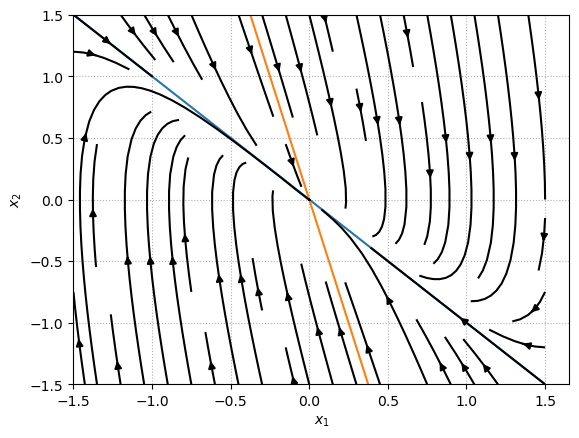

In [10]:
# 位相面図

w = 1.5
Y, X = np.mgrid[-w: w: 100j, -w: w: 100j]

A = np.array([[0, 1], [-4, -5]])
s, v = np.linalg.eig(A)

U = A[0, 0]*X + A[0, 1]*Y
V = A[1, 0]*X + A[1, 1]*Y

t = np.arange(-1.5, 1.5, 0.01)
fig, ax = plt.subplots()
plt.ylim(-1.5, 1.5)

if s.imag[0] == 0 and s.imag[1] == 0:
    ax.plot(t, (v[1,0]/v[0,0])*t, ls='-')
    ax.plot(t, (v[1,1]/v[0,1])*t, ls='-')

ax.streamplot(X, Y, U, V, density=0.7, color='k')
plot_set(ax, '$x_1$', '$x_2$')

### 状態フィードバック制御

#### 極配置法

システム　$\dot{x}$ = ${Ax + Bu}$ に状態フィードバック制御　${u = Fx}$ を施と閉ループシステム系は

$\dot{x}$ = $\left(A + BF\right)x$

となる。　行列 ${A +BF}$ の固有値の実部がすべて負になるように ${F}$を設計する

In [11]:
# アッカーマンの極配置アルゴリズム

A = [[0, 1], [-4, -5]]
B = [[0], [1]]
C = np.eye(2)
D = np.zeros([2, 1])
P = ss(A, B, C, D)

Pole = [-1, -1] 
F = -acker(P.A, P.B, Pole)

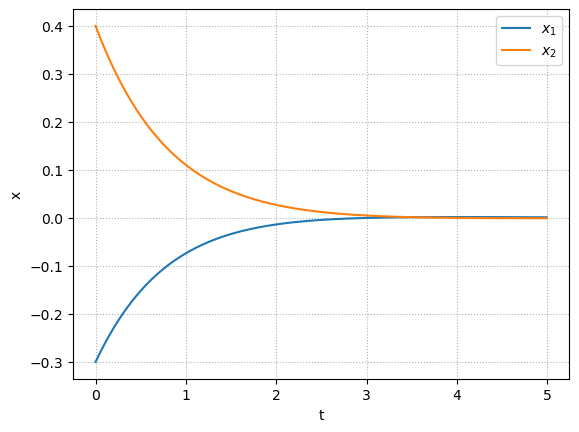

In [13]:
Acl = P.A + P.B*F
Pfbk = ss(Acl, P.B, P.C, P.D)

Td = np.arange(0, 5, 0.01)
X0 = [-0.3, 0.4]
x, t = initial(Pfbk, Td, X0)

fig, ax = plt.subplots()
ax.plot(t, x[:, 0], label='$x_1$')
ax.plot(t, x[:, 1], ls='-', label='$x_2$')
plot_set(ax, 't', 'x', 'best')

In [ ]:
,